# Feedback FxLMS — Karl and Sachau (2024)

Simulates feedback ANC with an error microphone and actuator. Renders no-ANC and feedback-controlled versions of the traffic, vehicle, and drill stimuli for listening comparisons. The room currently uses direct sound only.

Source: Karl and Sachau (2024), [“Comparison of feedback and feedforward active noise control concepts in an application with a partially open window”](https://past.isma-isaac.be/downloads/isma2024/proceedings/Contribution_554_proceeding_3.pdf).

**Step-size limitation.** The step size calculated with the method described by Karl and Sachau was too small for useful convergence in these simulations. Its value was scaled experimentally for each stimulus. Automatically selecting an appropriate step size remains an open implementation task.

Run the cells in order after installing the project from the repository root (see the [README](../../README.md)).

In [18]:
from pathlib import Path
from helpers.paths import WAVS_DIR

import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
from scipy.io import wavfile
from helpers.adaptMultichannel import adaptMultichannel
from helpers.truncatePathsModels import truncatePathsModels
from scipy.signal import butter, sosfilt

Simulation:

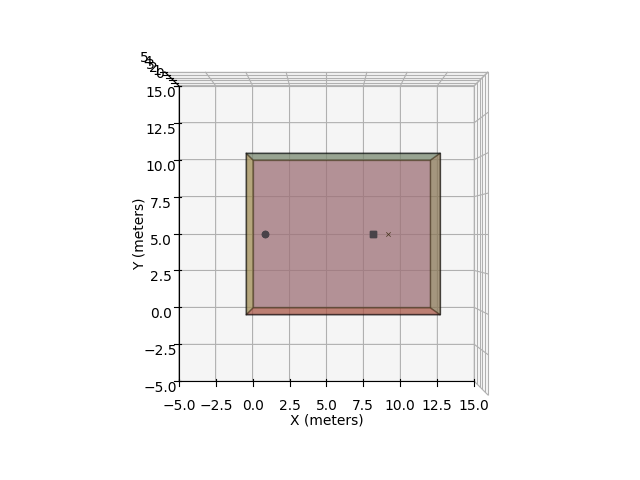

In [ ]:
fs = 48000
room = pra.ShoeBox([12, 10, 5], fs=fs, max_order=0)

# Noise source
room.add_source([1, 5, 2.5])

# Actuator: 1 m from the error microphone
room.add_source([8, 5, 2.5])

# Error microphone
room.add_microphone([9, 5, 2.5], fs=fs)

fig, ax = room.plot()
ax.view_init(elev=90, azim=-90)
ax.set_title("Top view of the room")
ax.set_xlim(-5, 15)
ax.set_ylim(-5, 15)
plt.grid(True)
plt.xlabel('X (meters)')
plt.ylabel('Y (meters)')
plt.show()

Obtain RIRs:

In [20]:
nActuators = 1
nErrorMics = 1

room.compute_rir()
primaryPaths = [room.rir[m][0] for m in range(nErrorMics)]
secondaryPaths = [[room.rir[m][s] for s in range(1, nActuators + 1)] for m in range(nErrorMics)]


primaryPaths = np.array([
    np.pad(h, (0, max(len(h) for h in primaryPaths) - len(h)))
    for h in primaryPaths
])

maxSecondaryLen  = max(len(h) for row in secondaryPaths for h in row)
secondaryPaths = np.array([
    [np.pad(h, (0, maxSecondaryLen - len(h))) for h in row]
    for row in secondaryPaths
])

print("Primary paths shape: ", primaryPaths.shape)
print("Secondary paths shape: ", secondaryPaths.shape)


Primary paths shape:  (1, 1202)
Secondary paths shape:  (1, 1, 222)


Algorithm:

Secondary paths model shape:  (1, 1, 222)
0.0
6.938893903907228e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
6.938893903907228e-18
3.469446951953614e-18
6.938893903907228e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
6.938893903907228e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
1.734723475976807e-18
1.734723475976807e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
6.938893903907228e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446951953614e-18
3.469446

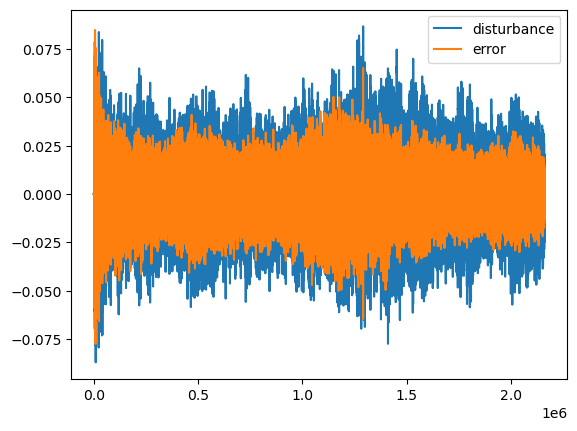

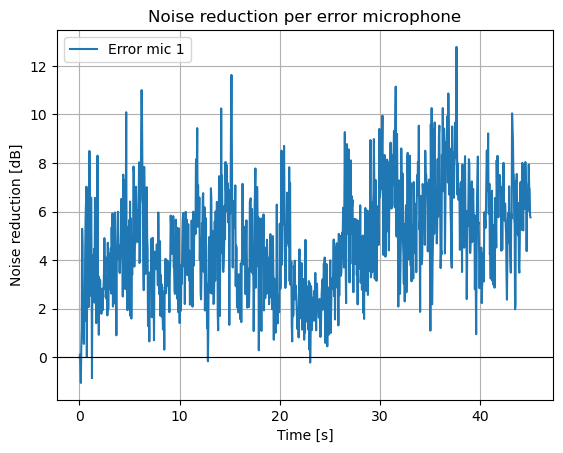

No ANC: ../../wavs/stimulus01_continuousTraffic_45s_noANC_FB.wav
FB: ../../wavs/stimulus01_continuousTraffic_45s_FB.wav
Exported duration: 15.0 s
Global reduction: 6.42310880301488 dB


In [21]:
# Disturbance
blocklength = 2048

stimulusFiles = [
    WAVS_DIR / "stimulus01_continuousTraffic_45s.wav",
    WAVS_DIR / "stimulus02_heavyVehiclePass_45s.wav",
    WAVS_DIR / "stimulus03_pneumaticDrill_45s.wav",
]
stimulusIndex = 0

stimulusFs, x = wavfile.read(stimulusFiles[stimulusIndex])

if stimulusFs != fs:
    raise ValueError(f"Stimulus fs is {stimulusFs} Hz, but simulation fs is {fs} Hz")

if x.ndim > 1:
    x = np.mean(x, axis=1)

if np.issubdtype(x.dtype, np.integer):
    integerInfo = np.iinfo(x.dtype)
    x = x.astype(np.float64) / max(abs(integerInfo.min), integerInfo.max)
else:
    x = x.astype(np.float64)

originalSampleCount = len(x)
nBlocks = int(np.ceil(originalSampleCount / blocklength))
N = nBlocks * blocklength
x = np.pad(x, (0, N - originalSampleCount))
t = np.arange(N) * (1/fs)

# Adaptive filter matrix definition
nTaps = 1024
wFilter = np.zeros((nActuators, nErrorMics, nTaps)) 

# Truncate IR models
secondaryPathsHat = secondaryPaths.copy()  # Ideal case where G = GHat
#secondaryPathsHat = truncatePathsModels(secondaryPaths.copy()) -> truncation worsens the algorithm

print("Secondary paths model shape: ", secondaryPathsHat.shape)

if(secondaryPathsHat.shape[2] > nTaps):
    print("Warning, L  > N")

# Running power estimate
referencePower = 0.0
errorPower = 0.0
beta = 1/nTaps
betaBlock = 1 - (1 - beta)**blocklength    # Accumulated beta in a block

Mp = primaryPaths.shape[1]
Np = blocklength + Mp - 1
pSpectrum = np.fft.rfft(primaryPaths, n=Np, axis=-1)
pBuffer = np.zeros(Mp - 1)

Mw = nTaps
wBuffer = np.zeros((nErrorMics, Mw - 1))

Mg = secondaryPaths.shape[2]
gBuffer = np.zeros((nActuators, Mg - 1))

MgHat = secondaryPathsHat.shape[2]
gHatBuffer = np.zeros((nActuators, MgHat - 1))

NgHatRef = blocklength + MgHat - 1
gHatRefSpectrum = np.fft.rfft(secondaryPathsHat, n=NgHatRef, axis=-1)
gHatRefBuffer = np.zeros((nErrorMics, MgHat - 1))

# Maximum secondary path delay
threshold = 0.1 * np.max(np.abs(secondaryPathsHat),axis=-1,keepdims=True)
secondaryDelays = np.argmax(np.abs(secondaryPathsHat) >= threshold,axis=-1)
maxSecondaryDelay = np.max(secondaryDelays)

# For testing
d = np.zeros((nErrorMics, N))
u = np.zeros((nActuators, N))
y = np.zeros((nErrorMics, N))
e = np.zeros((nErrorMics, N))

for k in range(nBlocks):
    # Block samples of X (simulation)
    xSignal = x[k*blocklength : (k+1)*blocklength]
    
    ################## Physical signals ##################

    # Disturbance signals (simulation)
    xSignalExt = np.concatenate([pBuffer, xSignal])
    xSpectrum = np.fft.rfft(xSignalExt, n=Np)
    dSignalsSpectrum = pSpectrum * xSpectrum
    dSignalsExt = np.fft.irfft(dSignalsSpectrum, n=Np, axis=-1)
    dSignals = dSignalsExt[:, Mp - 1:]
    pBuffer = xSignalExt[-(Mp - 1):]

    # Reference, Actuator, Control and Error signals (simulation)
    # This convolution has to be made sample by sample due to the feedback loop
    rSignals = np.zeros((nErrorMics, blocklength))
    eSignals = np.zeros((nErrorMics, blocklength))
    
    for n in range(blocklength):
        # Control sample
        controlSample = np.einsum(
            'emt,mt->e',
            secondaryPaths[:, :, 1:],
            gBuffer[:, ::-1]
        )

        # Error sample
        errorSample = dSignals[:, n] - controlSample

        # Estimated control sample
        estimatedControlSample = np.einsum(
            'emt,mt->e',
            secondaryPathsHat[:, :, 1:],
            gHatBuffer[:, ::-1]
        )

        # Reference sample
        referenceSample = errorSample + estimatedControlSample

        # Actuator sample
        actuatorSample = wFilter[:, :, 0] @ referenceSample
        actuatorSample += np.einsum(
            'met,et->m',
            wFilter[:, :, 1:],
            wBuffer[:, ::-1]
        )

        # Save samples into signal blocks
        rSignals[:, n] = referenceSample
        eSignals[:, n] = errorSample

        # Update buffers
        wBuffer[:, :-1] = wBuffer[:, 1:]
        wBuffer[:, -1] = referenceSample
        gBuffer[:, :-1] = gBuffer[:, 1:]
        gBuffer[:, -1] = actuatorSample
        gHatBuffer[:, :-1] = gHatBuffer[:, 1:]
        gHatBuffer[:, -1] = actuatorSample
       
    
    ################## Algorithm ##################

    # Compute the filtered reference matrix
    rSignalsExt = np.concatenate([gHatRefBuffer, rSignals], axis=1)
    rSignalsSpectrum = np.fft.rfft(rSignalsExt, n=NgHatRef, axis=-1)
    frSignalsSpectrum = np.einsum('emf,kf->emkf', gHatRefSpectrum, rSignalsSpectrum)
    frSignalsExt = np.fft.irfft(frSignalsSpectrum, n=NgHatRef, axis=-1)
    frSignals = frSignalsExt[..., MgHat - 1:]
    gHatRefBuffer = rSignalsExt[:, -(MgHat - 1):]

    # Calculate the running power estimate
    referencePowerBlock = np.mean(frSignals**2)
    errorPowerBlock = np.mean(eSignals**2)
    referencePower = (1 - betaBlock) * referencePower + betaBlock * referencePowerBlock
    errorPower = (1 - betaBlock) * errorPower + betaBlock * errorPowerBlock

    # Calculate the VSS
    muVss = (2 * errorPower) / (nTaps* referencePower + 1e-12)
    maxMu = 1 / (referencePower * (nTaps + 2 + 2 * maxSecondaryDelay)**2 + 1e-12)
    mu = min(muVss, maxMu) * 10000 # 10 was obtained experimentally

    if k % 10 == 0:
        #print(mu)
        print(np.max(np.abs(rSignals - dSignals)))
    
    # Calculate the leakage factor
    leakageBlock = (1 - mu / nTaps**2)

    # LMS algorithm
    wFilter = adaptMultichannel(
        frSignals,
        eSignals,
        nTaps,
        blocklength,
        wFilter,
        mu,
        #leakageBlock
    )
    
    ################## For testing ##################
    start = k * blocklength
    end = (k + 1) * blocklength

    d[:, start:end] = dSignals
    e[:, start:end] = eSignals

plt.plot(d[0], label="disturbance")
plt.plot(e[0], label="error")
plt.legend()
plt.show()

dBlocks = d.reshape(nErrorMics, nBlocks, blocklength)
eBlocks = e.reshape(nErrorMics, nBlocks, blocklength)

dPower = np.mean(dBlocks**2, axis=-1)
ePower = np.mean(eBlocks**2, axis=-1)

noiseReductionDb = 10 * np.log10(
    (dPower + 1e-12) / (ePower + 1e-12)
)

blockTime = (np.arange(nBlocks) + 0.5) * blocklength / fs

plt.figure()

for nError in range(nErrorMics):
    plt.plot(
        blockTime,
        noiseReductionDb[nError],
        label=f'Error mic {nError + 1}'
    )

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Noise reduction per error microphone')
plt.xlabel('Time [s]')
plt.ylabel('Noise reduction [dB]')
plt.grid()
plt.legend()
plt.show()

# Export assessed interval: 30–45 s
errorMicIndex = 0
preRollSamples = int(30 * fs)
endSample = originalSampleCount

dToExport = d[
    errorMicIndex,
    preRollSamples:endSample
]

eToExport = e[
    errorMicIndex,
    preRollSamples:endSample
]

stimulusName = Path(stimulusFiles[stimulusIndex]).stem

noAncOutputPath = (
    str(WAVS_DIR / f"{stimulusName}_noANC_FB.wav")
)

fbOutputPath = (
    str(WAVS_DIR / f"{stimulusName}_FB.wav")
)

wavfile.write(
    noAncOutputPath,
    fs,
    dToExport.astype(np.float32)
)

wavfile.write(
    fbOutputPath,
    fs,
    eToExport.astype(np.float32)
)

rmsD = np.sqrt(np.mean(dToExport**2))
rmsE = np.sqrt(np.mean(eToExport**2))
reductionDb = 20 * np.log10(
    (rmsD + 1e-12) / (rmsE + 1e-12)
)

print("No ANC:", noAncOutputPath)
print("FB:", fbOutputPath)
print("Exported duration:", len(eToExport) / fs, "s")
print("Global reduction:", reductionDb, "dB")
